# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Sneha Kanjwani
**Student ID:** 023-24-0273
**Section:** H
**GitHub:** https://github.com/snehakanjwani30/Machine-Learning-Labs
**Kaggle:** https://www.kaggle.com/snehakanjwani
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:** 
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [3]:
# Task 1 — load spam.csv, inspect shape/head/class balance
spam_df = pd.read_csv('spam.csv', encoding='latin-1')
print("Shape:", spam_df.shape)
print("First 5 rows:")
display(spam_df.head())
print("Class balance:")
print(spam_df['v1'].value_counts())
print("Class percentages:")
print((spam_df['v1'].value_counts(normalize=True) * 100).round(2))

Shape: (5572, 5)
First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Class balance:
v1
ham     4825
spam     747
Name: count, dtype: int64
Class percentages:
v1
ham     86.59
spam    13.41
Name: proportion, dtype: float64


In [4]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets_df = pd.read_csv('Tweets.csv')

print("Original shape:", tweets_df.shape)
print("\nFirst 5 rows:")
display(tweets_df.head())

print("\nOriginal sentiment balance:")
print(tweets_df['airline_sentiment'].value_counts())

print("\nOriginal sentiment percentages:")
print((tweets_df['airline_sentiment'].value_counts(normalize=True) * 100).round(2))

tweets_df = tweets_df[
    tweets_df['airline_sentiment'].isin(['positive', 'negative'])
].copy()

print("\nShape after removing neutral tweets:", tweets_df.shape)

print("\nPositive/negative balance:")
print(tweets_df['airline_sentiment'].value_counts())

print("\nPositive/negative percentages:")
print((tweets_df['airline_sentiment'].value_counts(normalize=True) * 100).round(2))

Original shape: (14640, 15)

First 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)



Original sentiment balance:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Original sentiment percentages:
airline_sentiment
negative    62.69
neutral     21.17
positive    16.14
Name: proportion, dtype: float64

Shape after removing neutral tweets: (11541, 15)

Positive/negative balance:
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

Positive/negative percentages:
airline_sentiment
negative    79.53
positive    20.47
Name: proportion, dtype: float64


**Answer 2 (Task A — spam):**
The practical problem is to identify whether an SMS message is a normal message (ham) or an unwanted spam message. This can help a system decide which messages should be treated as spam. It is a binary classification problem because there are only two classes: ham and spam.


**Answer 2 (Task B — sentiment):**
The practical problem is to identify whether an airline-related tweet expresses a positive or negative sentiment. This can help understand customers' opinions about airlines. It is a binary classification problem because neutral tweets are removed, leaving only two classes: positive and negative.


---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [5]:
# Task 3 — clean text
spam_df = spam_df[['v1', 'v2']].copy()
spam_df.columns = ['label', 'message']
spam_df['message'] = spam_df['message'].str.lower()
display(spam_df.head())

,label,message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


In [6]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
spam_df['label'] = spam_df['label'].map({'ham': 0, 'spam': 1})
X = spam_df['message']
y = spam_df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print("Training samples:", X_train_vec.shape[0])
print("Testing samples:", X_test_vec.shape[0])
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Training samples: 4457
Testing samples: 1115
Vocabulary size: 7701


**Answer 4 (why fit on training data only):**
The vectorizer must be fitted only on the training data to prevent data leakage. The test data should remain unseen during training, so we only use the fitted vectorizer to transform the test messages.


---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy: 0.9605
Precision: 1.0
Recall: 0.7047
F1-score: 0.8268


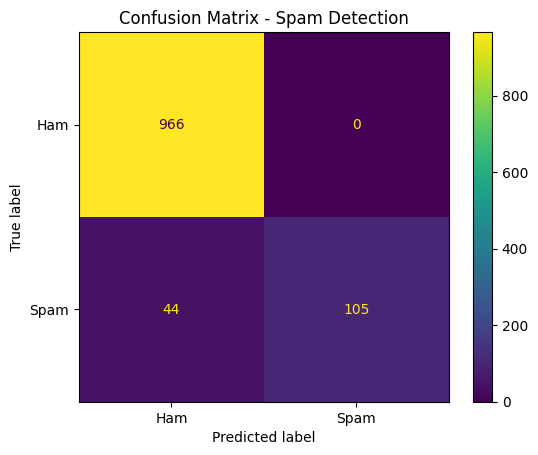

In [7]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix

model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot()
plt.title("Confusion Matrix - Spam Detection")
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9605 |
| Precision | 1.0 |
| Recall | 0.7047 |
| F1-score | 0.8268 |

**Answer 6:**
For spam filtering, a false positive can be more harmful because a genuine message may be incorrectly marked as spam and the user may miss an important message. A false negative allows a spam message to reach the user's inbox, which is inconvenient but usually does not hide a genuine message. Therefore, I would prioritize precision when tuning the model because higher precision means that messages classified as spam are more likely to actually be spam. Since precision is already 1.0 while recall is only 0.7047, further tuning should aim to raise recall without letting precision fall.


---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [8]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_names = vectorizer.get_feature_names_out()

log_prob_ham = model.feature_log_prob_[0]
log_prob_spam = model.feature_log_prob_[1]

spam_difference = log_prob_spam - log_prob_ham

top_spam_indices = np.argsort(spam_difference)[-15:][::-1]
top_spam_words = feature_names[top_spam_indices]
top_ham_indices = np.argsort(spam_difference)[:15]
top_ham_words = feature_names[top_ham_indices]

print("Top 15 words associated with SPAM:")
print(top_spam_words)
print("Top 15 words associated with HAM:")
print(top_ham_words)

Top 15 words associated with SPAM:
['claim' 'prize' '150p' 'www' 'uk' 'tone' '18' 'guaranteed' 'cs' '1000'
 'nokia' '500' 'txt' '16' 'service']
Top 15 words associated with HAM:
['gt' 'lt' 'my' 'ok' 'll' 'later' 'lor' 'da' 'but' 'home' 'come' 'he'
 'sorry' 'me' 'how']


**Answer 7:**
The top spam-associated words mostly match my intuition because words such as “claim,” “prize,” “guaranteed,” “1000,” and “service” are commonly found in promotional or spam messages. The ham-associated words such as “my,” “ok,” “later,” “home,” “sorry,” and “how” are more common in normal conversations. Overall, the words learned by the model make sense for distinguishing spam from regular messages.


In [9]:
# Task 8 — test your own messages
my_messages = [
    "Congratulations! You have won a free cash prize. Click now to claim your reward!",
    "Hey, are you coming to university tomorrow?",
    "URGENT! You have been selected for a free prize. Call now to claim it."
]

my_messages_clean = [message.lower() for message in my_messages]

my_messages_vec = vectorizer.transform(my_messages_clean)

my_predictions = model.predict(my_messages_vec)

for message, prediction in zip(my_messages, my_predictions):
    label = "Spam" if prediction == 1 else "Ham"
    print("Message:", message)
    print("Prediction:", label)
    print()


Message: Congratulations! You have won a free cash prize. Click now to claim your reward!
Prediction: Spam

Message: Hey, are you coming to university tomorrow?
Prediction: Ham

Message: URGENT! You have been selected for a free prize. Call now to claim it.
Prediction: Spam



**Answer 8:**
The predictions matched my expectations for all three messages. The two messages containing words such as “prize,” “free,” “claim,” and “urgent” were classified as spam, while the normal message about coming to university was classified as ham. This shows that the trained model can recognize useful word patterns associated with spam and normal messages.


---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/snehakanjwani/task-a-sms-spam-detection-using-naive-bayes

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [10]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
import re

tweets_df = tweets_df[['text', 'airline_sentiment']].copy()

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # remove links
    text = re.sub(r'@\w+', '', text)             # remove @mentions
    text = re.sub(r'#', '', text)                # remove # symbol
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)     # remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

tweets_df['text'] = tweets_df['text'].apply(clean_tweet)
tweets_df['label'] = tweets_df['airline_sentiment'].map({
    'negative': 0,
    'positive': 1
})
X = tweets_df['text']
y = tweets_df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

print("Training samples:", X_train_vec.shape[0])
print("Testing samples:", X_test_vec.shape[0])
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Training samples: 9232
Testing samples: 2309
Vocabulary size: 8748


**Answer 12:**
 I removed links, @mentions, and the # symbol because these are common in tweets and usually do not provide useful information for sentiment classification. This extra cleaning is useful for tweets because they contain more social-media-specific elements than SMS messages.


---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy: 0.835
Precision: 1.0
Recall: 0.1945
F1-score: 0.3257


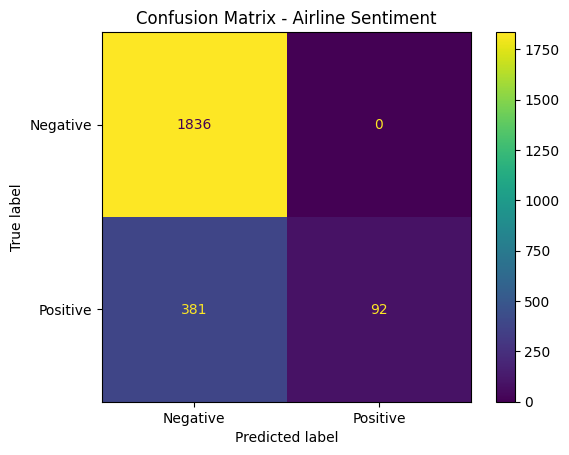

In [11]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix

model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
)

disp.plot()
plt.title("Confusion Matrix - Airline Sentiment")
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.835 |
| Precision | 1.0 |
| Recall | 0.1945 |
| F1-score | 0.3257 |

**Answer 14:**
Naive Bayes did worse on sentiment than on spam, with recall dropping from 0.7047 to 0.1945 and F1 from 0.8268 to 0.3257. The 0.835 accuracy is misleading because about 80% of the tweets are negative, so always predicting "negative" would already score about 79.5%. The model has perfect precision but misses most positive tweets, which is mainly a class-imbalance effect, since MultinomialNB's class prior and word counts favor the majority class. The independence assumption also hurts here: sentiment depends on word combinations, negation, and sarcasm (e.g. "not good"), while spam relies on fairly independent keywords like "prize" and "claim", so the assumption is more reasonable for spam SMS.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/snehakanjwani/task-b-airline-sentiment-using-naive-bayes

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9605 | 0.8350 |
| Precision | 1.0 | 1.0 |
| Recall | 0.7047 | 0.1945 |
| F1-score | 0.8268 | 0.3257 |

In [12]:
# Task 18 — train Logistic Regression on Task A's vectorized features

X_spam = spam_df['message']
y_spam = spam_df['label']

X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam,
    y_spam,
    test_size=0.2,
    random_state=42,
    stratify=y_spam
)

spam_vectorizer = TfidfVectorizer()

X_train_spam_vec = spam_vectorizer.fit_transform(X_train_spam)
X_test_spam_vec = spam_vectorizer.transform(X_test_spam)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_spam_vec, y_train_spam)

lr_pred = lr_model.predict(X_test_spam_vec)

lr_accuracy = accuracy_score(y_test_spam, lr_pred)
lr_precision = precision_score(y_test_spam, lr_pred)
lr_recall = recall_score(y_test_spam, lr_pred)
lr_f1 = f1_score(y_test_spam, lr_pred)

print("Accuracy:", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall:", round(lr_recall, 4))
print("F1-score:", round(lr_f1, 4))

Accuracy: 0.9722
Precision: 0.9917
Recall: 0.7987
F1-score: 0.8848


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9605 | 0.9722 |
| Precision | 1.0 | 0.9917 |
| Recall | 0.7047 | 0.7987 |
| F1-score | 0.8268 | 0.8848 |

**Answer 18 (which wins, and does it match expectations):**
Logistic Regression performed better overall than Naive Bayes on Task A, with higher accuracy, recall, and F1-score. Naive Bayes had slightly higher precision, while Logistic Regression achieved a better balance between precision and recall. This result is reasonable because Logistic Regression learns all word weights jointly, so correlated words are not double-counted the way they are in Naive Bayes, although it still does not model word order or context. Therefore, the higher F1-score is consistent with the expectation that a discriminative model handles correlated features better.


---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
Naive Bayes suited the spam detection task better than the airline sentiment task because it achieved higher accuracy, recall, and F1-score. The spam messages contained common predictive words such as “claim,” “prize,” and “guaranteed,” which made classification easier. I was surprised that "gt" and "lt" (HTML-encoded symbols) and informal words like "lor" and "da" were among the strongest ham indicators, and that tokens like "150p", "www" and "uk" were strong spam indicators. Logistic Regression performed better than Naive Bayes on Task A, with higher accuracy, recall, and F1-score. However, Naive Bayes achieved slightly higher precision. One limitation I observed is that Naive Bayes treats words independently and may not understand word relationships, context, or sarcasm. This limitation was more noticeable in the sentiment task, where its recall and F1-score were much lower.


**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/snehakanjwani/task-a-sms-spam-detection-using-naive-bayes
- Task B: https://www.kaggle.com/code/snehakanjwani/task-b-airline-sentiment-using-naive-bayes

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted